In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("feature_engineering_dataset.csv")

In [3]:
df.head(10)

,Date,Store_ID,Product_Category,Region,Promotion_Type,Sales,Customers,Holiday
0,2023-01-01,S3,Electronics,South,BOGO,569,180.0,No
1,2023-01-02,S1,Clothing,North,NaN,348,156.0,No
2,2023-01-03,S3,Clothing,West,NaN,1899,87.0,No
3,2023-01-04,S3,Grocery,North,Discount,851,54.0,No
4,2023-01-05,S1,Electronics,South,BOGO,1711,84.0,Yes
5,2023-01-06,S1,Grocery,West,BOGO,969,27.0,No
6,2023-01-07,S3,Electronics,East,NaN,573,64.0,No
7,2023-01-08,S2,Clothing,West,BOGO,980,106.0,No
8,2023-01-09,S3,Clothing,East,NaN,1916,194.0,No
9,2023-01-10,S3,Clothing,East,Discount,359,187.0,No


In [4]:
df.isnull().sum()

Date                  0
Store_ID              0
Product_Category      0
Region                0
Promotion_Type      283
Sales                 0
Customers            37
Holiday               0
dtype: int64

In [6]:
df.isnull().sum()

Date                  0
Store_ID              0
Product_Category      0
Region                0
Promotion_Type      283
Sales                 0
Customers            37
Holiday               0
dtype: int64

In [11]:
df.head()

,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price,journey_day,journey_month,journey_year
0,2022-02-11,SpiceJet,SG,8709,18:55,Delhi,02h 10m,non-stop,21:05,Mumbai,"5,953",11,2,2022
1,2022-02-11,SpiceJet,SG,8157,06:20,Delhi,02h 20m,non-stop,08:40,Mumbai,"5,953",11,2,2022
2,2022-02-11,AirAsia,I5,764,04:25,Delhi,02h 10m,non-stop,06:35,Mumbai,"5,956",11,2,2022
3,2022-02-11,Vistara,UK,995,10:20,Delhi,02h 15m,non-stop,12:35,Mumbai,"5,955",11,2,2022
4,2022-02-11,Vistara,UK,963,08:50,Delhi,02h 20m,non-stop,11:10,Mumbai,"5,955",11,2,2022


In [11]:
df.isnull().sum()

Date                  0
Store_ID              0
Product_Category      0
Region                0
Promotion_Type      283
Sales                 0
Customers            37
Holiday               0
dtype: int64

In [13]:
df["Customers"] = pd.to_numeric(df["Customers"], errors="coerce").fillna(0).astype(int)

In [14]:
df["Promotion_Type"] = pd.to_numeric(df["Promotion_Type"], errors="coerce").fillna(0).astype(int)

In [15]:
df.isnull().sum()

Date                0
Store_ID            0
Product_Category    0
Region              0
Promotion_Type      0
Sales               0
Customers           0
Holiday             0
dtype: int64

In [23]:
df["Date"] = pd.to_datetime(df["Date"])
df["year"] = df["Date"].dt.year
df["month"] = df["Date"].dt.month
df["day"] = df["Date"].dt.day
df["dayofweek"] = df["Date"].dt.dayofweek
df["is_month_start"] = df["Date"].dt.is_month_start.astype(int)
df["is_month_end"] = df["Date"].dt.is_month_end.astype(int)



In [24]:
df.head()

,Date,Sales,Customers,Holiday,Store_ID_S2,Store_ID_S3,Product_Category_Electronics,Product_Category_Grocery,Region_North,Region_South,Region_West,year,month,day,dayofweek,is_month_start,is_month_end
0,2023-01-01,569,180,0,False,True,True,False,False,True,False,2023,1,1,6,1,0
1,2023-01-02,348,156,0,False,False,False,False,True,False,False,2023,1,2,0,0,0
2,2023-01-03,1899,87,0,False,True,False,False,False,False,True,2023,1,3,1,0,0
3,2023-01-04,851,54,0,False,True,False,True,True,False,False,2023,1,4,2,0,0
4,2023-01-05,1711,84,1,False,False,True,False,False,True,False,2023,1,5,3,0,0


In [16]:
from sklearn.preprocessing import LabelEncoder

In [18]:
df['Promotion_Type'].value_counts()

Promotion_Type
0    731
Name: count, dtype: int64

In [19]:
df['Holiday'].value_counts()

Holiday
No     660
Yes     71
Name: count, dtype: int64

In [20]:
le = LabelEncoder() 

df["Holiday"] = le.fit_transform(df["Holiday"])

In [22]:
df.head()

,Date,Sales,Customers,Holiday,Store_ID_S2,Store_ID_S3,Product_Category_Electronics,Product_Category_Grocery,Region_North,Region_South,Region_West
0,2023-01-01,569,180,0,False,True,True,False,False,True,False
1,2023-01-02,348,156,0,False,False,False,False,True,False,False
2,2023-01-03,1899,87,0,False,True,False,False,False,False,True
3,2023-01-04,851,54,0,False,True,False,True,True,False,False
4,2023-01-05,1711,84,1,False,False,True,False,False,True,False


### One hot encoding

In [21]:
df = pd.get_dummies(df, columns=[
    "Store_ID",
    "Product_Category",
    "Region",
    "Promotion_Type"
], drop_first=True)

In [25]:
print(df.skew)

<bound method DataFrame.skew of           Date  Sales  Customers  Holiday  Store_ID_S2  Store_ID_S3  \
0   2023-01-01    569        180        0        False         True   
1   2023-01-02    348        156        0        False        False   
2   2023-01-03   1899         87        0        False         True   
3   2023-01-04    851         54        0        False         True   
4   2023-01-05   1711         84        1        False        False   
..         ...    ...        ...      ...          ...          ...   
726 2024-12-27    860         87        0        False        False   
727 2024-12-28   1548        114        0        False        False   
728 2024-12-29   1527        175        0        False        False   
729 2024-12-30   1499          0        0         True        False   
730 2024-12-31   1907         68        1        False         True   

     Product_Category_Electronics  Product_Category_Grocery  Region_North  \
0                            True     

### Feature Creation

In [26]:
df["Sales_per_Customer"] = df["Sales"] / df["Customers"]

In [27]:
df.head()

,Date,Sales,Customers,Holiday,Store_ID_S2,Store_ID_S3,Product_Category_Electronics,Product_Category_Grocery,Region_North,Region_South,Region_West,year,month,day,dayofweek,is_month_start,is_month_end,Sales_per_Customer
0,2023-01-01,569,180,0,False,True,True,False,False,True,False,2023,1,1,6,1,0,3.161111
1,2023-01-02,348,156,0,False,False,False,False,True,False,False,2023,1,2,0,0,0,2.230769
2,2023-01-03,1899,87,0,False,True,False,False,False,False,True,2023,1,3,1,0,0,21.827586
3,2023-01-04,851,54,0,False,True,False,True,True,False,False,2023,1,4,2,0,0,15.759259
4,2023-01-05,1711,84,1,False,False,True,False,False,True,False,2023,1,5,3,0,0,20.369048


### Standard scalar

In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df[["Sales","Customers"]] = scaler.fit_transform(df[["Sales","Customers"]])

In [29]:
import numpy as np

df["Sales_log"] = np.log1p(df["Sales"]) # log transformation

C:\Users\dell8\AppData\Roaming\Python\Python311\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [30]:
df.head(10)

,Date,Sales,Customers,Holiday,Store_ID_S2,Store_ID_S3,Product_Category_Electronics,Product_Category_Grocery,Region_North,Region_South,Region_West,year,month,day,dayofweek,is_month_start,is_month_end,Sales_per_Customer,Sales_log
0,2023-01-01,-1.028118,1.320276,0,False,True,True,False,False,True,False,2023,1,1,6,1,0,3.161111,NaN
1,2023-01-02,-1.452933,0.899170,0,False,False,False,False,True,False,False,2023,1,2,0,0,0,2.230769,NaN
2,2023-01-03,1.528458,-0.311509,0,False,True,False,False,False,False,True,2023,1,3,1,0,0,21.827586,0.927610
3,2023-01-04,-0.486047,-0.890529,0,False,True,False,True,True,False,False,2023,1,4,2,0,0,15.759259,-0.665624
4,2023-01-05,1.167077,-0.364147,1,False,False,True,False,False,True,False,2023,1,5,3,0,0,20.369048,0.773379
5,2023-01-06,-0.259223,-1.364273,0,False,False,False,True,False,False,True,2023,1,6,4,0,0,35.888889,-0.300056
6,2023-01-07,-1.020430,-0.715069,0,False,True,True,False,False,False,False,2023,1,7,5,0,0,8.953125,NaN
7,2023-01-08,-0.238079,0.021867,0,True,False,False,False,False,False,True,2023,1,8,6,0,0,9.245283,-0.271912
8,2023-01-09,1.561136,1.565921,0,False,True,False,False,False,False,False,2023,1,9,0,0,0,9.876289,0.940451
9,2023-01-10,-1.431788,1.443099,0,False,True,False,False,False,False,False,2023,1,10,1,0,0,1.919786,NaN


Text(0.5, 1.0, 'outlier detection')

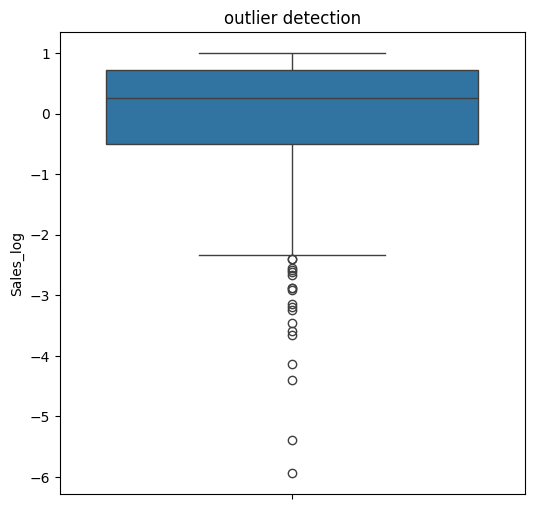

In [32]:
plt.figure(figsize=(6,6))
sns.boxplot(df['Sales_log'])
plt.title("outlier detection")

<function matplotlib.pyplot.show(close=None, block=None)>

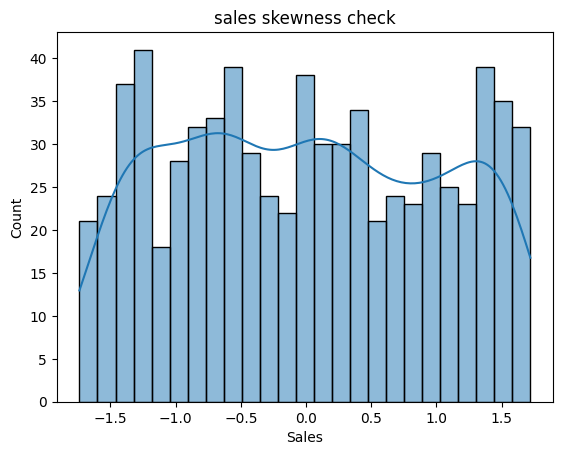

In [34]:
plt.Figure(figsize=(6,7))
sns.histplot(df['Sales'], bins= 25 ,kde = True)
plt.title("sales skewness check")
plt.show